In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

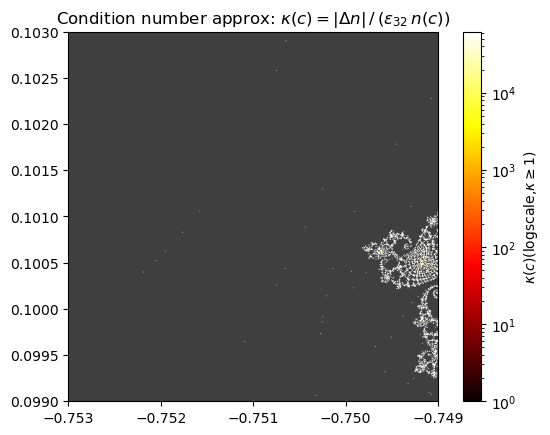

In [5]:
res = 512
max_iterations = 1000

# seahorse valley
x = np.linspace(-0.7530, -0.7490, res)
y = np.linspace(0.0990, 0.1030, res)
C = (x[np.newaxis,:] + 1j * y[:, np.newaxis]).astype(np.complex128)

eps32 = float(np.finfo(np.float32).eps)
delta = np.maximum(eps32 * np.abs(C), 1e-10)

def escape_count(C, max_iter):
    z = np.zeros_like(C)
    cnt = np.full(C.shape, max_iter, dtype=np.int32)
    esc = np.zeros(C.shape, dtype=bool)

    for k in range(max_iter):
        z[~esc] = z[~esc]**2 + C[~esc]
        newly = ~esc & (np.abs(z) > 2.0)
        cnt[newly] = k
        esc[newly] = True

    return cnt

n_base = escape_count(C, max_iterations).astype(float)
n_perturb = escape_count(C + delta, max_iterations).astype(float)
dn = np.abs(n_base - n_perturb)
kappa = np.where(n_base > 0, dn / (eps32 * n_base), np.nan)
cmap_k = plt.cm.hot.copy()
cmap_k.set_bad('0.25')
vmax = np.nanpercentile(kappa, 99)

fig, ax = plt.subplots()

im = ax.imshow(kappa, cmap=cmap_k, origin='lower',
                extent=[-0.7530,-0.7490,0.0990,0.1030],
                norm=LogNorm(vmin=1,vmax=vmax))
fig.colorbar(im, ax=ax, label=r'$\kappa(c)$(logscale,$\kappa\geq1$)')
ax.set_title(r'Condition number approx: $\kappa(c)=|\Delta n|\,/\,(\varepsilon_{32}\,n(c))$')
# fig.savefig("L08_Computer_Arithmetics/Sensitivity_Map.png", dpi=300, bbox_inches='tight')
plt.show()